## air sea heat flux data

In [1]:
import numpy as np
import xarray as xr
from glob import glob
import pandas as pd

from scipy import signal, stats

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import palettable.colorbrewer as cb 

from statsmodels.tsa.stattools import ccf
from PIL import Image
import io

from process_raw_data import process_data, decimal_year_to_datetime, plot_filter_response
from stats_plots import plot_timeseries, acf_calc_plot, integral_time_scale, critical_r, plot_hovmöller, plot_crosscorr, plot_crosscorr_gif ,lagged_std, zero_lag_corr, zero_lag_corr_regions

In [2]:
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")

lats = ds.latitude.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats]


region_labels = []

for i in range(len(lats) - 1):
    lat1 = lats[i]
    lat2 = lats[i + 1]

    def fmt(lat):
        if lat > 0:
            return f"{abs(int(lat))}°N"
        elif lat < 0:
            return f"{abs(int(lat))}°S"
        else:
            return "0°"

    region_labels.append(f"{fmt(lat1)}–{fmt(lat2)}")

print(region_labels)


['65°N–60°N', '60°N–55°N', '55°N–45°N', '45°N–35°N', '35°N–26°N', '26°N–16°N', '16°N–5°N', '5°N–5°S', '5°S–11°S', '11°S–25°S', '25°S–35°S']


## process the data 
# deseasonalize - detrend - low pass filter

only need to call the following once

In [3]:
ds["time"] = decimal_year_to_datetime(ds.time.values)


In [4]:
# ds = ds.rename({"number_regions": "lat"})


In [5]:
# heat transport

mht = ds.mht.isel(lat=slice(1,None)).dropna(dim="time", how="any") # drop 65
mht_mean = mht.mean(dim="posterior_samples")
mht_raw_anom = process_data(mht_mean, anomalies=True)
mht_filtered = process_data(mht_mean)
# adapt lats to drop 65
lats = lats[1:]  # drop 65
lat_labels = lat_labels[1:]  # drop 65
n_lats = len(lats)

# # surface heat flux
## hf only goes until idx 10
# # defined as the heatflux between the latitude 1 and 2 
hf = ds.qnet.dropna(dim="time", how="any")
hf_mean = hf.mean(dim="posterior_samples")
hf_filtered = process_data(hf_mean)


regions = np.arange(hf_filtered.sizes["number_regions"])

## show butterworth - where does it cutoff

In [29]:

# plot_filter_response(cutoff=1/1, fs=4, order=4)


## colors for plotting

In [30]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 18,
    'axes.labelsize'  : 18,
    # ticks
    'xtick.labelsize' : 16,
    'ytick.labelsize' : 16,
    # legend
    'legend.fontsize' : 14,
    'legend.title_fontsize': 14,
    # colorbar
    'figure.titlesize': 20,
})

cmap = plt.cm.coolwarm 

colors = [cmap(i / (len(lats) - 1)) for i in range(len(lats))]

label_map = {lat: lat_labels[i] for i, lat in enumerate(lats)}

### colormap correlations
cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.diverging.RdBu_11_r.mpl_colors
)
colors = cmap(np.linspace(0, 1, 40))
sliced_cmap_corr = mcolors.ListedColormap(colors)

### colormap mht
cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.sequential.YlOrBr_9.mpl_colors
)
colors = cmap(np.linspace(0, 1, 20))
sliced_cmap_mht = mcolors.ListedColormap(colors)

### colormap mht anomalies
cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.diverging.PuOr_11_r.mpl_colors
)
colors = cmap(np.linspace(0, 1, 20))
sliced_cmap_anom = mcolors.ListedColormap(colors)

#### colormap hf
cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.diverging.RdBu_9.mpl_colors
)
colors = cmap(np.linspace(0, 1, 20))
sliced_cmap_hf = mcolors.ListedColormap(colors)


## plot the timeseries raw and proceseed

In [31]:
# sel_lat = [35.0]
# plot_timeseries(
#     data={"raw anomalies": mht_raw_anom, "processed": mht_filtered},
#     lats=sel_lat,
#     all_lats=lats,
#     labels=lat_labels,
    
# )

## before doing any kind of correlation - get N_eff for MHT 

In [32]:
time_unit = "years"  # or "months"
if time_unit == "months":
    del_t = 3
if time_unit == "years":
    del_t = 0.25
    
def compute_n_eff_and_r_crit(
        data,
        coord_values, # lats
        coord_labels, # lats labels for mht
        dim,
        del_t,
        time_unit,
        plateau_values=None,
        plot=False):

    N = data.sizes["time"]
    print(f"Total number of samples: {N}")

    n_effs = {}
    its_dict = {}

    if plateau_values is None:
        plateau_values = []

    for idx, value in enumerate(coord_values):

        ts = data.isel({dim: idx})

        # if value in plateau_values:
        #     method = "plateau"
        # else:
        method = "0cross"

        its, max_lags = integral_time_scale(ts, del_t=del_t, method=method)

        N_eff = N * del_t / its
        n_effs[value] = N_eff
        its_dict[value] = its

        print(
            f"{coord_labels[idx]}: ITS = {its:.2f} {time_unit}, "
            f"N_eff = {N_eff:.1f}"
        )

        if plot:
            acf_calc_plot(
                ts,
                N_eff=12,
                plot=True,
                title=f"Autocorrelation at {coord_labels[idx]}"
            )

    r_crits = {value: critical_r(neff) for value, neff in n_effs.items()}
    
    return n_effs, r_crits, its_dict


def significance_mask(data, ref_lats, all_lags, nlags, r_crits):
    corr_matrix = np.full((len(lats), len(all_lags)), np.nan)

    for ref_lat in ref_lats:

        ref_idx = np.argmin(np.abs(lats - ref_lat))
        ts_ref = data.isel(lat=ref_idx).values

        corr_matrix = np.full((len(lats), len(all_lags)), np.nan)
        significance_mask = np.zeros((len(lats), len(all_lags)), dtype=bool)

        r_ref = r_crits[ref_lat]

        for i, lat in enumerate(lats):

            ts = data.isel(lat=i).values

            pos_corr, _ = ccf(ts_ref, ts, nlags=nlags, alpha=0.05)
            neg_corr, _ = ccf(ts, ts_ref, nlags=nlags, alpha=0.05)

            full_corr = np.concatenate([neg_corr[1:][::-1], pos_corr])
            corr_matrix[i, :] = full_corr

            r_lat = r_crits[lat]

            # use the smaller effective sample size (larger critical r)
            r_crit = max(r_ref, r_lat)
            print(f"for ref lat: {ref_lat} and {lat}: r crit = {r_crit:.2f}")

            significance_mask[i, :] = np.abs(full_corr) >= r_crit

In [33]:
n_effs_mht, r_crits_mht, its_mht = compute_n_eff_and_r_crit(
    mht_filtered,
    coord_values=lats,
    coord_labels=lat_labels,
    dim="lat",
    del_t=del_t,
    time_unit=time_unit,
    plateau_values=[45, 35],
    plot=False
)

n_effs_hf, r_crits_hf, its_hf = compute_n_eff_and_r_crit(
    hf_filtered,
    coord_values=regions,
    coord_labels=region_labels,
    dim="number_regions",
    del_t=del_t,
    time_unit=time_unit,
    plot=False
)

Total number of samples: 66
60.0°N: ITS = 1.65 years, N_eff = 10.0
55.0°N: ITS = 1.92 years, N_eff = 8.6
45.0°N: ITS = 2.87 years, N_eff = 5.8
35.0°N: ITS = 2.02 years, N_eff = 8.2
26.0°N: ITS = 0.75 years, N_eff = 22.1
16.0°N: ITS = 0.72 years, N_eff = 22.8
5.0°N: ITS = 0.73 years, N_eff = 22.5
5.0°S: ITS = 0.75 years, N_eff = 22.1
11.0°S: ITS = 0.75 years, N_eff = 22.1
25.0°S: ITS = 0.73 years, N_eff = 22.7
35.0°S: ITS = 0.40 years, N_eff = 41.3
Total number of samples: 66
65°N–60°N: ITS = 0.79 years, N_eff = 20.8
60°N–55°N: ITS = 1.16 years, N_eff = 14.2
55°N–45°N: ITS = 0.75 years, N_eff = 21.9
45°N–35°N: ITS = 0.74 years, N_eff = 22.2
35°N–26°N: ITS = 0.41 years, N_eff = 40.6
26°N–16°N: ITS = 0.76 years, N_eff = 21.8
16°N–5°N: ITS = 0.74 years, N_eff = 22.4
5°N–5°S: ITS = 0.78 years, N_eff = 21.2
5°S–11°S: ITS = 0.39 years, N_eff = 42.4
11°S–25°S: ITS = 0.78 years, N_eff = 21.2
25°S–35°S: ITS = 0.72 years, N_eff = 23.0


## cross correlation
## split year, before and after 

In [34]:


dates = []
for year in range(2008, 2020):
    for month in ["02", "05", "08", "11"]:
        dates.append(f"{year}-{month}-01")

min_samples = 8  # skip frames where prior/later would be too small to be meaningful
frames = []

for date in dates:
    ds_prior = mht_filtered.sel(time=slice(None, date))
    ds_later = mht_filtered.sel(time=slice(date, None))

    if ds_prior.sizes["time"] < min_samples or ds_later.sizes["time"] < min_samples:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    plot_crosscorr_gif(ds_prior, lats, lat_labels, significance=True, n_effs=n_effs_mht,
                   title=f"Prior to {date} (n={ds_prior.sizes['time']})",
                   cmap=sliced_cmap_corr, ax=axes[0])
    plot_crosscorr_gif(ds_later, lats, lat_labels, significance=True, n_effs=n_effs_mht,
                   title=f"After {date} (n={ds_later.sizes['time']})",
                   cmap=sliced_cmap_corr, ax=axes[1])

    fig.suptitle(date)
    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    plt.close(fig)

frames[0].save(
    "figures/cross_corr/gif/crosscorr_evolution.gif",
    save_all=True,
    append_images=frames[1:],
    duration=500,
    loop=0
)

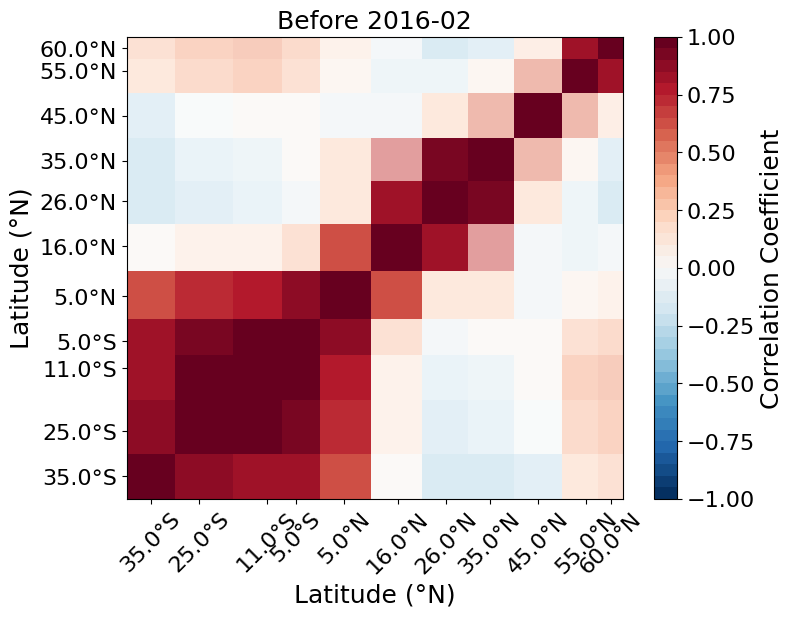

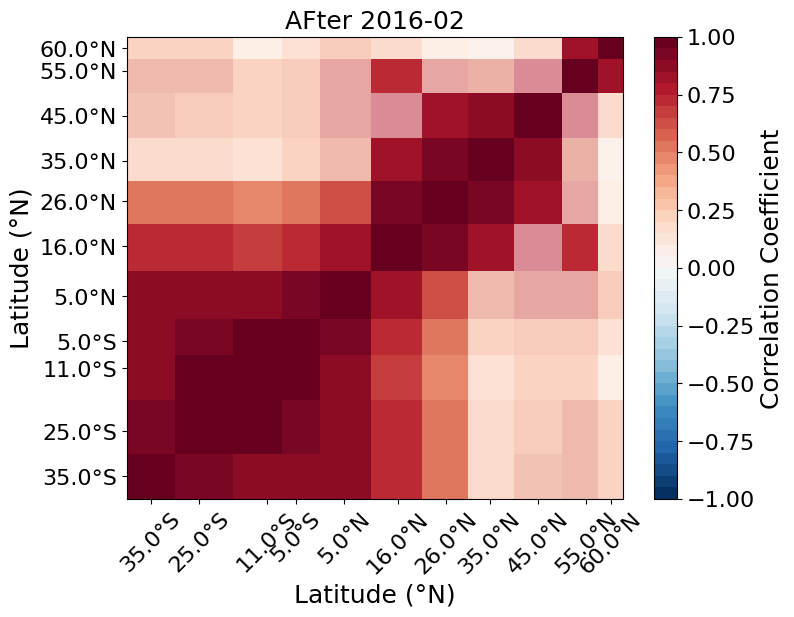

In [35]:
year_sel = 2016
month = "02"
mht_bsel = mht_filtered.sel(time=slice(None, f"{year_sel}-{month}-01"))
mht_asel = mht_filtered.sel(time=slice(f"{year_sel}-{month}-01", None))

plot_crosscorr(mht_bsel, lats, lat_labels, significance=True, n_effs=n_effs_mht, title=f"Before {year_sel}-{month}",cmap=sliced_cmap_corr, savefig=False)
plot_crosscorr(mht_asel, lats, lat_labels, significance=True, n_effs=n_effs_mht, title=f"AFter {year_sel}-{month}", cmap=sliced_cmap_corr, savefig=False)


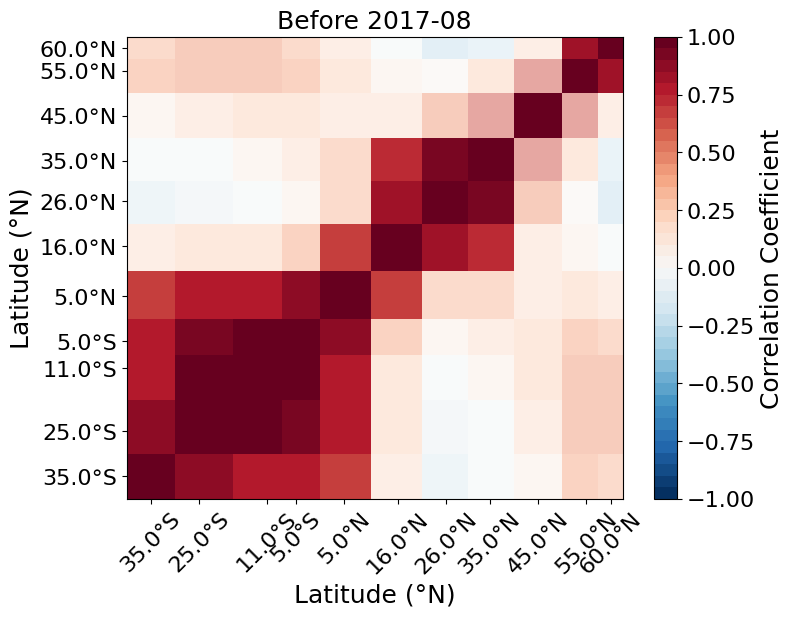

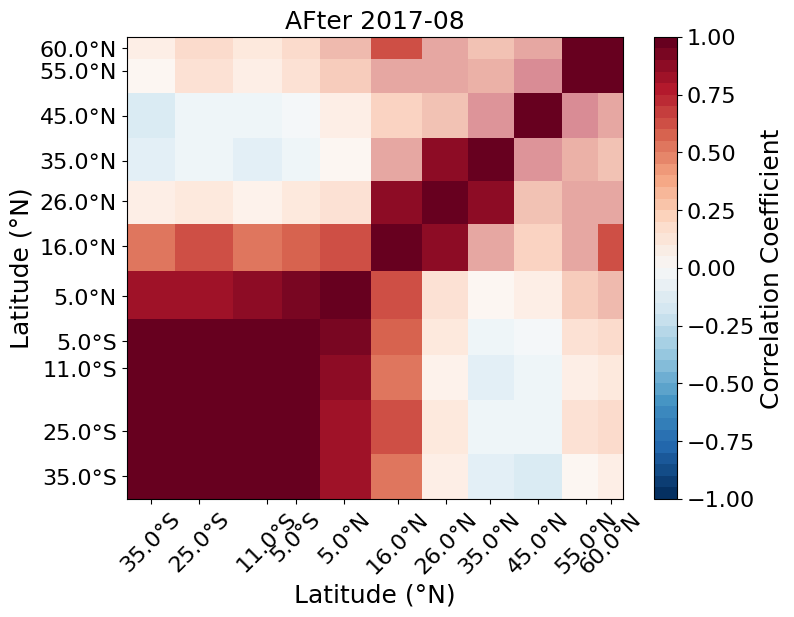

In [36]:
year_sel = 2017
month = "08"
mht_bsel = mht_filtered.sel(time=slice(None, f"{year_sel}-{month}-01"))
mht_asel = mht_filtered.sel(time=slice(f"{year_sel}-{month}-01", None))

plot_crosscorr(mht_bsel, lats, lat_labels, significance=True, n_effs=n_effs_mht, title=f"Before {year_sel}-{month}",cmap=sliced_cmap_corr, savefig=False)
plot_crosscorr(mht_asel, lats, lat_labels, significance=True, n_effs=n_effs_mht, title=f"AFter {year_sel}-{month}", cmap=sliced_cmap_corr, savefig=False)


## lets do the same for F_S
before just look at time series

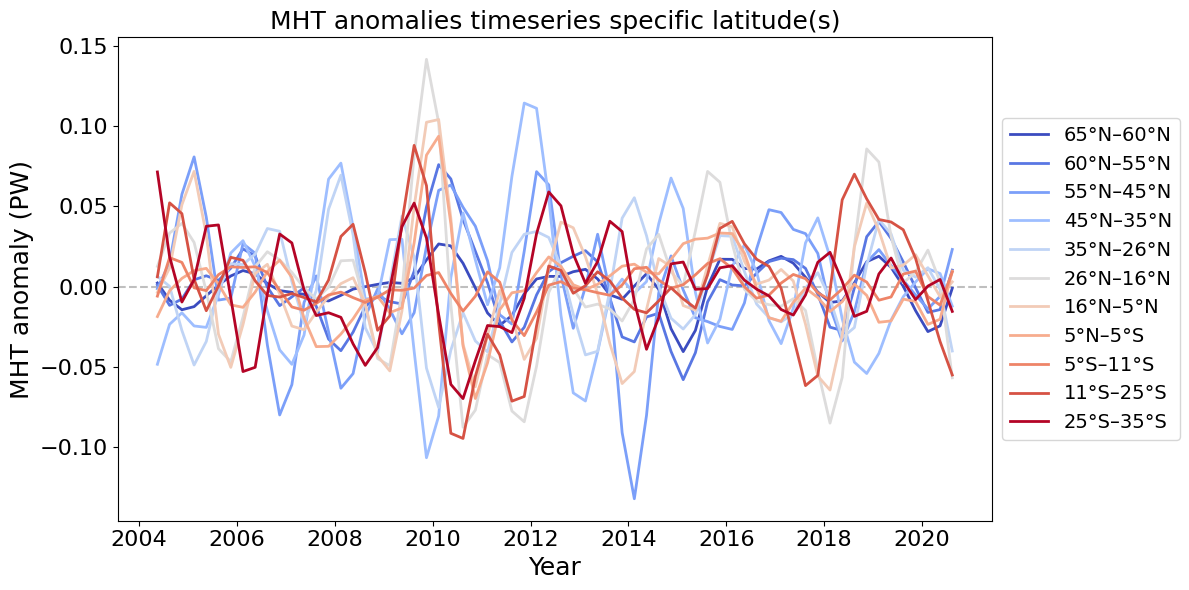

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'MHT anomalies timeseries specific latitude(s)'}, xlabel='Year', ylabel='MHT anomaly (PW)'>)

In [37]:
plot_timeseries(
    hf_filtered,
    regions,
    all_lats=regions,
    labels=region_labels,
    lat_dim="number_regions" 
)

## cross correlation gif

['65°N–60°N',
 '60°N–55°N',
 '55°N–45°N',
 '45°N–35°N',
 '35°N–26°N',
 '26°N–16°N',
 '16°N–5°N',
 '5°N–5°S',
 '5°S–11°S',
 '11°S–25°S',
 '25°S–35°S']

In [ ]:

dates = []
for year in range(2008, 2020):
    for month in ["02", "05", "08", "11"]:
        dates.append(f"{year}-{month}-01")

min_samples = 8  # skip frames where prior/later would be too small to be meaningful
frames = []

for date in dates:
    ds_prior = hf_filtered.sel(time=slice(None, date))
    ds_later = hf_filtered.sel(time=slice(date, None))

    if ds_prior.sizes["time"] < min_samples or ds_later.sizes["time"] < min_samples:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    plot_crosscorr_gif(ds_prior, regions, region_labels, significance=True, n_effs=n_effs_hf,
                   title=f"Prior to {date} (n={ds_prior.sizes['time']})",
                   cmap=sliced_cmap_anom, ax=axes[0])
    plot_crosscorr_gif(ds_later, regions, region_labels, significance=True, n_effs=n_effs_hf,
                   title=f"After {date} (n={ds_later.sizes['time']})",
                   cmap=sliced_cmap_anom, ax=axes[1])

    fig.suptitle(date)
    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    plt.close(fig)

frames[0].save(
    "figures/cross_corr/gif/crosscorr_evolution_hf.gif",
    save_all=True,
    append_images=frames[1:],
    duration=500,
    loop=0
)

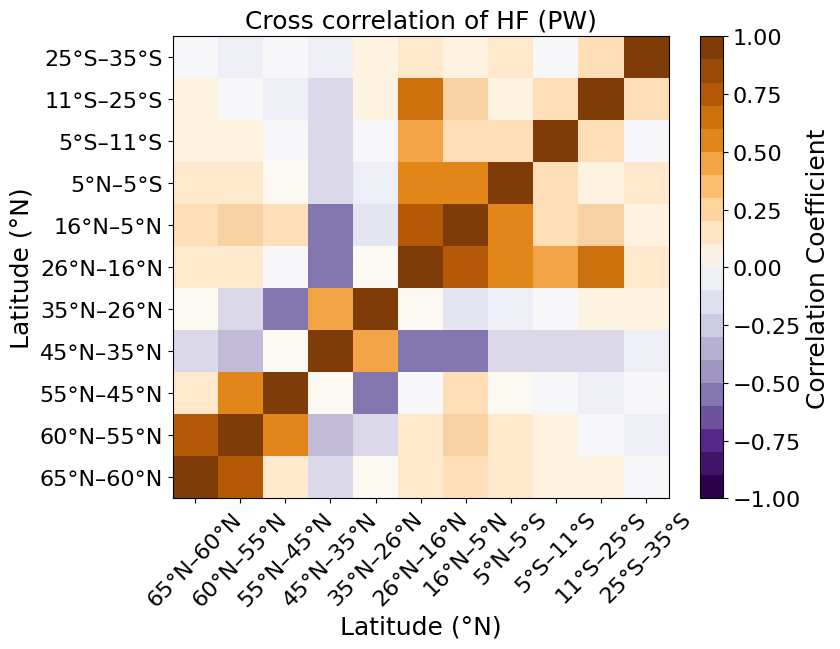

In [44]:
plot_crosscorr(
    hf_filtered,
    lats=regions,
    lat_labels=region_labels,
    cmap=sliced_cmap_anom,
    significance=True,
    n_effs=n_effs_hf,
    title="Cross correlation of HF (PW)"
)


In [16]:
# n_effs_array = xr.DataArray(
#     list(n_effs_mht.values()),
#     dims="lat",
#     coords={"lat": list(n_effs_mht.keys())},
#     name="N_eff"
# )
# its_array = xr.DataArray(
#     list(its_mht.values()),
#     dims="lat",
#     coords={"lat": list(its_mht.keys())},
#     name="ITS"
# )
# r_crits_array = xr.DataArray(
#     list(r_crits_mht.values()),
#     dims="lat",
#     coords={"lat": list(r_crits_mht.keys())},
#     name="critical r"
# )

# n_effs_raw, r_crits_raw, its_raw = compute_n_eff_and_r_crit(
#     mht_mean,
#     coord_values=lats,
#     coord_labels=lat_labels,
#     dim="lat",
#     del_t=del_t,
#     time_unit=time_unit,
#     plateau_values=[45, 35],
#     plot=False
# )

# n_effs_raw_array = xr.DataArray(
#     list(n_effs_raw.values()), dims="lat",
#     coords={"lat": list(n_effs_raw.keys())}, name="N_eff_raw"
# )
# its_raw_array = xr.DataArray(
#     list(its_raw.values()), dims="lat",
#     coords={"lat": list(its_raw.keys())}, name="ITS_raw"
# )

# linewidth = 2
# fig, ax1 = plt.subplots(figsize=(14, 8))

# # N_eff — red family, left axis
# color="tab:red"
# ax1.plot(n_effs_array.lat, n_effs_array.values,
#          label="N_eff (filtered)", color=color, linestyle="-", linewidth=linewidth)
# ax1.plot(n_effs_raw_array.lat, n_effs_raw_array.values,
#          label="N_eff (raw)", color=color, linestyle="--", alpha=0.6, linewidth=linewidth)
# ax1.set_ylabel("N_eff", color=color)
# ax1.tick_params(axis="y", labelcolor=color)
# ax1.set_xlabel("Latitude °N")

# # ITS — blue family, right axis
# color="darkblue"
# ax2 = ax1.twinx()
# ax2.plot(its_array.lat, its_array.values,
#          label="ITS (filtered)", color=color, linestyle="-", linewidth=linewidth)
# ax2.plot(its_raw_array.lat, its_raw_array.values,
#          label="ITS (raw)", color=color, linestyle="--", alpha=0.6, linewidth=linewidth)
# ax2.set_ylabel("ITS (years)",color=color)
# ax2.tick_params(axis="y", labelcolor=color)

# # combined legend (twinx axes don't share one automatically)
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", bbox_to_anchor=(1.4, 0.5))

# fig.tight_layout()
# plt.show()

In [17]:
# plot_hovmöller(mht_filtered, lats, cmap=sliced_cmap_anom, savefig=False, anomalies=False)
# plot_hovmöller(hf_filtered, lats[:-1], cmap=sliced_cmap_hf, savefig=False, anomalies=False)

In [18]:
# year_sel = 2008
# plot_crosscorr(mht_filtered.sel(time=slice(None, f"{year_sel}-01-01")), lats, lat_labels, significance=False, title=f"mht before {year_sel}", cmap=sliced_cmap_corr, savefig=False)
# plot_crosscorr(hf_filtered.sel(time=slice(None, f"{year_sel}-01-01")), lats, lat_labels, significance=False, title=f"hf before {year_sel}", cmap=sliced_cmap_corr, savefig=False)


In [19]:
lats

array([ 60.,  55.,  45.,  35.,  26.,  16.,   5.,  -5., -11., -25., -35.])

## quantify when coherence between MHT bands break
coherence band: 35°S- 26°N (maybe including 35°N if it doesnt work)

In [20]:
mht.lat.values

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [21]:
def block_coherence_index(
        mht,
        r_crits,
        lat_idx,
        lats,
        window=8,
        lat_dim="lat",
        time_dim="time"):
    # select block from lat idx (0 == 60°N)
    block = mht.isel({lat_dim: lat_idx})
    block_lats = lats[lat_idx]
    times = block[time_dim].values

    coherence = []
    valid_times = []
    n_valid_list = []


    for t_idx in range(window, len(times)):

        window_data = block.isel({time_dim: slice(t_idx-window, t_idx)})

        vals = window_data.transpose(time_dim, lat_dim).values
        corr_mat = np.corrcoef(vals.T)
        # shape of corr_mat is (n lats in block , n lats in block)
        # correlation between each pair lats in block in that time window

        # Apply significance threshold
        for i in range(len(block_lats)):
            for j in range(i+1, len(block_lats)):
                r_crit = max(r_crits[block_lats[i]], r_crits[block_lats[j]])
                if np.abs(corr_mat[i, j]) < r_crit:
                    corr_mat[i, j] = np.nan
                    corr_mat[j, i] = np.nan

        # triu indices gives upper triangles of matrix, k=1 is offset 1 (without diagonal!)
        iu = np.triu_indices(len(block_lats), k=1)
        pair_vals = corr_mat[iu]
        coherence.append(np.nanmean(pair_vals) if np.sum(~np.isnan(pair_vals)) >= 2 else np.nan)
        valid_times.append(times[t_idx])
        n_valid_list.append(np.sum(~np.isnan(corr_mat[iu])))

    coherence_da = xr.DataArray(coherence, coords=[valid_times], dims=[time_dim])
    n_valid_da = xr.DataArray(n_valid_list, coords=[valid_times], dims=[time_dim])

    return coherence_da, n_valid_da
    

In [22]:
def block_coherence_split(
        mht,
        lat_idx,
        lats,
        significance=True,
        r_crits=None,
        lat_dim="lat",
        time_dim="time",
        min_samples = 4
        ):
    # select block from lat idx (0 == 60°N)
    block = mht.isel({lat_dim: lat_idx})
    block_lats = lats[lat_idx]
    times = block[time_dim].values
    coherence_prior = []
    coherence_later = []
    valid_times_prior = []
    valid_times_later = []
    n_valid_list_prior = []
    n_valid_list_later = []

    for t_idx, time in enumerate(times):
        if t_idx  < min_samples:
            continue
        if t_idx > len(times) - min_samples -2:
            continue
        # split data at that time idx
        prior_data = block.isel({time_dim: slice(None, t_idx)})  
        later_data = block.isel({time_dim: slice(t_idx+1, None)})
        
        # make matrix 
        prior_vals = prior_data.transpose(time_dim, lat_dim).values
        later_vals = later_data.transpose(time_dim, lat_dim).values
        
        # correlate
        prior_corr_mat = np.corrcoef(prior_vals.T)
        later_corr_mat = np.corrcoef(later_vals.T)
        # shape of corr_mat is (n lats in block , n lats in block)
        # correlation between each pair lats in block in that time window
        
        # apply signifance masking for both
        for i in range(len(block_lats)):
            for j in range(i+1, len(block_lats)):
                if significance:
                    r_crit = max(r_crits[block_lats[i]], r_crits[block_lats[j]])
                else: 
                    r_crit = 0
                    
                if np.abs(prior_corr_mat[i, j]) < r_crit:
                    prior_corr_mat[i, j] = np.nan
                    prior_corr_mat[j, i] = np.nan
                if np.abs(later_corr_mat[i, j]) < r_crit:
                    later_corr_mat[i, j] = np.nan
                    later_corr_mat[j, i] = np.nan
        
        # triu indices gives upper triangles of matrix, k=1 is offset 1 (without diagonal!)
        iu = np.triu_indices(len(block_lats), k=1)
        prior_pair_vals = prior_corr_mat[iu]
        later_pair_vals = later_corr_mat[iu]
        
        return prior_corr_mat, later_corr_mat

lat_block = (-35, 35)

lat_min, lat_max = lat_block
mask = (lats >= lat_min) & (lats <= lat_max)
lat_idx = np.where(mask)[0]

prior_corr_mat, later_corr_mat = block_coherence_split(
    mht_filtered,
    r_crits=r_crits_mht,
    lat_idx=lat_idx,
    lats=lats,
    significance=True
)

In [23]:
#### the rest of block coherence plot after 
#later_pair_vals = later_corr_mat[iu]


#         coherence_prior.append(np.nanmean(prior_pair_vals)if np.sum(~np.isnan(prior_pair_vals)) >= 2 else np.nan)
#         coherence_later.append(np.nanmean(later_pair_vals)if np.sum(~np.isnan(later_pair_vals)) >= 2 else np.nan)
        
#         valid_times_prior.append(times[t_idx - 1])  # last time included in prior
#         valid_times_later.append(times[t_idx + 1])  # first time included in later (since later starts at t_idx+1)
        
#         n_valid_list_prior.append(np.sum(~np.isnan(prior_corr_mat[iu])))
#         n_valid_list_later.append(np.sum(~np.isnan(later_corr_mat[iu])))

#     coherence_da_prior = xr.DataArray(coherence_prior, coords=[valid_times_prior], dims=[time_dim])
#     n_valid_da_prior = xr.DataArray(n_valid_list_prior, coords=[valid_times_prior], dims=[time_dim])
#     coherence_da_later = xr.DataArray(coherence_later, coords=[valid_times_later], dims=[time_dim])
#     n_valid_da_later = xr.DataArray(n_valid_list_later, coords=[valid_times_later], dims=[time_dim])
    
#     return coherence_da_prior, n_valid_da_prior, coherence_da_later, n_valid_da_later

# # lat_block = (-35, 35)
# # lat_block = (-35, 5)
# # lat_block = (16, 35)
# lat_block = (-11, 16)
# for lat_block in [(-35, 26), (-25, 26), (-11, 16), (16, 35), (-35, 5)]:

#     lat_min, lat_max = lat_block
#     mask = (lats >= lat_min) & (lats <= lat_max)
#     lat_idx = np.where(mask)[0]

#     coherence_prior_raw, n_valid_prior_raw, coherence_later_raw, n_valid_later_raw = block_coherence_split(
#         mht_filtered,
#         r_crits=r_crits_mht,
#         lat_idx=lat_idx,
#         lats=lats,
#         significance=False
#     )

#     coherence_prior_sig, n_valid_prior_sig, coherence_later_sig, n_valid_later_sig = block_coherence_split(
#         mht_filtered,
#         r_crits=r_crits_mht,
#         lat_idx=lat_idx,
#         lats=lats,
#         significance=True
#     )

#     # fig, (ax0, ax1, ax2) = plt.subplots(
#     #     1, 3, figsize=(18, 6), gridspec_kw={"width_ratios": [1, 3, 3]}
#     # )
#     fig, (ax0, ax1) = plt.subplots(
#         1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [1, 6]}
#     )

#     selected = mask

#     ax0.scatter(np.zeros(np.sum(selected)), lats[selected], color="tab:red", s=60, zorder=3, label="selected")
#     ax0.scatter(np.zeros(np.sum(~selected)), lats[~selected], color="lightgray", s=60, zorder=3, label="not selected")
#     ax0.set_yticks(lats)
#     ax0.set_yticklabels([f"{l:g}°" for l in lats])
#     ax0.set_xticks([])
#     ax0.set_title(f"Block: {lat_min}° to {lat_max}°N")
#     ax0.set_ylabel("Latitude")
#     ax0.set_xlim(-1, 1)
#     ax0.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18))

#     color_pr="tab:red"
#     color_lat="tab:blue"
#     ax1.plot(coherence_prior_raw.time, coherence_prior_raw.values, label="2004-split", color=color_pr)
#     ax1.plot(coherence_later_raw.time, coherence_later_raw.values, label="split-2020", color=color_lat)
#     ax1.set_title("No significance masking")
#     ax1.set_xlabel("Year")
#     ax1.set_ylabel("Correlation Coeff.")
#     ax1.set_ylim(0, 1)
#     ax1.legend()
#     ax1.grid()
#     # ax1b = ax1.twinx()
#     # ax1b.scatter(n_valid_prior_raw.time, n_valid_prior_raw.values, color=color_pr, alpha=0.3)
#     # ax1b.scatter(n_valid_later_raw.time, n_valid_later_raw.values, color=color_lat, alpha=0.3)
#     # ax1b.set_ylabel("n_valid pairs", color="red")
#     # ax1b.tick_params(axis="y", labelcolor="red")


#     # ax2.plot(coherence_prior_sig.time, coherence_prior_sig.values, label="2004-split", color=color_pr)
#     # ax2.plot(coherence_later_sig.time, coherence_later_sig.values, label="split-2020", color=color_lat)
#     # # ax2.set_title("Significance masked")
#     # ax2.set_xlabel("Year")
#     # ax2.set_ylim(0, 1)
#     # ax2.legend()
#     # ax2.grid()
#     # ax2b = ax2.twinx()
#     # ax2b.scatter(n_valid_prior_sig.time, n_valid_prior_sig.values, color=color_pr, alpha=0.5)
#     # ax2b.scatter(n_valid_later_sig.time, n_valid_later_sig.values, color=color_lat, alpha=0.5)
#     # ax2b.set_ylabel("n_valid pairs", color="red")
#     # ax2b.tick_params(axis="y", labelcolor="red")

#     fig.suptitle("Latitude block coherence index")
#     fig.tight_layout()
#     plt.show()


In [24]:
def build_region_labels(lat_bounds):
    """Convert latitude bounds array into region labels."""
    def fmt(lat):
        return f"{abs(lat):.0f}°{'N' if lat >= 0 else 'S'}"
    return [f"{fmt(lat_bounds[i])}-{fmt(lat_bounds[i+1])}" for i in range(len(lat_bounds) - 1)]

def build_lat_labels(lat_bounds):
    return [f"{abs(l):.0f}°{'N' if l >= 0 else 'S'}" for l in lat_bounds]

def compute_corr_matrix(mht, hf, lat_dim="lat", region_dim="number_regions", time_dim="time"):
    """
    Compute zero-lag correlation between each MHT latitude band and each 
    heat flux region. Returns a (lat x region) DataArray.
    """
    lats = mht[lat_dim].values
    regions = hf[region_dim].values
    corr_matrix = np.zeros((len(lats), len(regions)))

    for i, lat in enumerate(lats):
        ts1 = mht.sel({lat_dim: lat})
        for j, reg in enumerate(regions):
            ts2 = hf.sel({region_dim: reg})
            corr_matrix[i, j] = xr.corr(ts1, ts2, dim=time_dim).item()

    return xr.DataArray(corr_matrix, coords=[lats, regions], dims=[lat_dim, region_dim])

# def plot_corr_heatmap(corr_matrix, lat_bounds, ax=None, title=None, vmax=1.0):
#     """Plot correlation matrix as a heatmap with annotated values."""
#     if ax is None:
#         fig, ax = plt.subplots(figsize=(10, 8))

#     region_labels = build_region_labels(lat_bounds)
#     lat_labels = build_lat_labels(lat_bounds)  

#     im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
#     #fig.colorbar(im, ax=ax, label="Correlation Coefficient", shrink=0.8)
#     ax.set_xticks(range(len(region_labels)))
#     ax.set_xticklabels(region_labels, rotation=45, ha="right")
#     ax.set_yticks(range(len(lat_labels)))
#     ax.set_yticklabels(lat_labels)

#     ax.set_xlabel("Heat Flux Region")
#     ax.set_ylabel("MHT Latitude Band")
#     ax.set_title(title if title else "0-lag Correlation: MHT vs Heat Flux")
#     ax.invert_xaxis()
#     # annotate values
#     for i in range(corr_matrix.shape[0]):
#         for j in range(corr_matrix.shape[1]):
#             val = corr_matrix.values[i, j]
#             ax.text(j, i, f"{val:.2f}", ha="center", va="center",
#                      color="white" if abs(val) > 0.6 else "black", fontsize=8)

#     return im

# def compare_pre_post(mht, hf, lat_bounds, split_date="2008-01-01",
#                       lat_dim="lat", region_dim="number_regions", time_dim="time"):
#     """Compare MHT-HF correlation structure before vs after a given date."""
#     mht_pre = mht.sel({time_dim: slice(None, split_date)})
#     hf_pre = hf.sel({time_dim: slice(None, split_date)})
#     mht_post = mht.sel({time_dim: slice(split_date, None)})
#     hf_post = hf.sel({time_dim: slice(split_date, None)})

#     corr_pre = compute_corr_matrix(mht_pre, hf_pre, lat_dim, region_dim, time_dim)
#     corr_post = compute_corr_matrix(mht_post, hf_post, lat_dim, region_dim, time_dim)

#     fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
#     im1 = plot_corr_heatmap(corr_pre, lat_bounds, ax=axes[0], title=f"Pre-{split_date}")
#     im2 = plot_corr_heatmap(corr_post, lat_bounds, ax=axes[1], title=f"Post-{split_date}")

#     fig.colorbar(im2, ax=axes, label="Correlation Coefficient", shrink=0.8)
#     plt.savefig(f"figures/0lag/corr_matrix_split_{split_date}.png", dpi=300, bbox_inches='tight')
#     plt.show()

#     return corr_pre, corr_post

## boxes including equator 

block cohrence index is correlation up until this timepoint

lat idx:  [ 4  5  6  7  8  9 10]


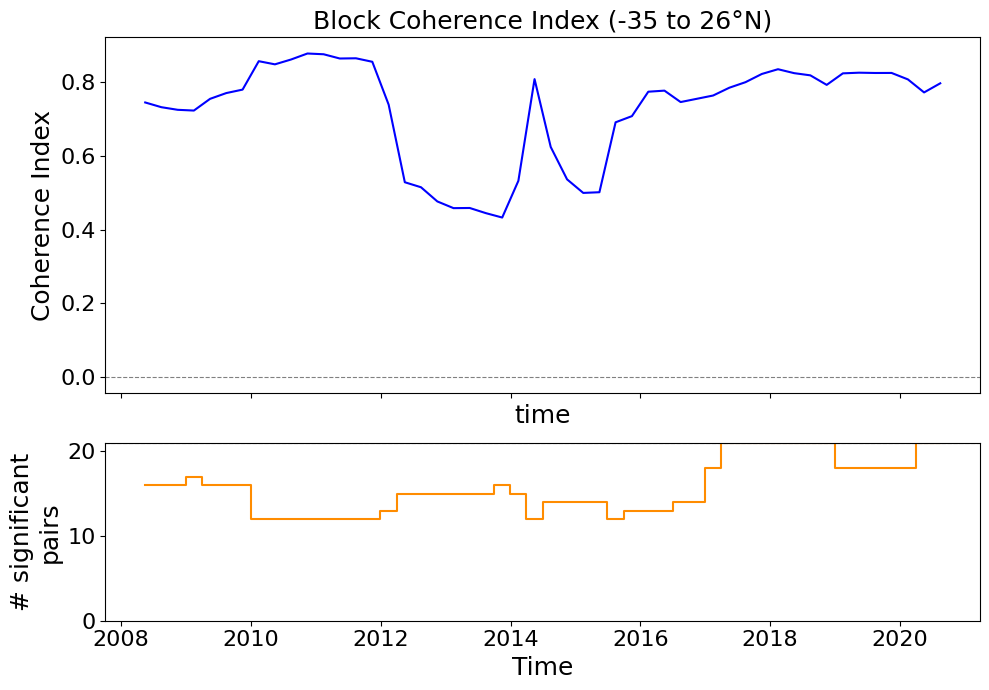

lat idx:  [4 5 6 7 8 9]


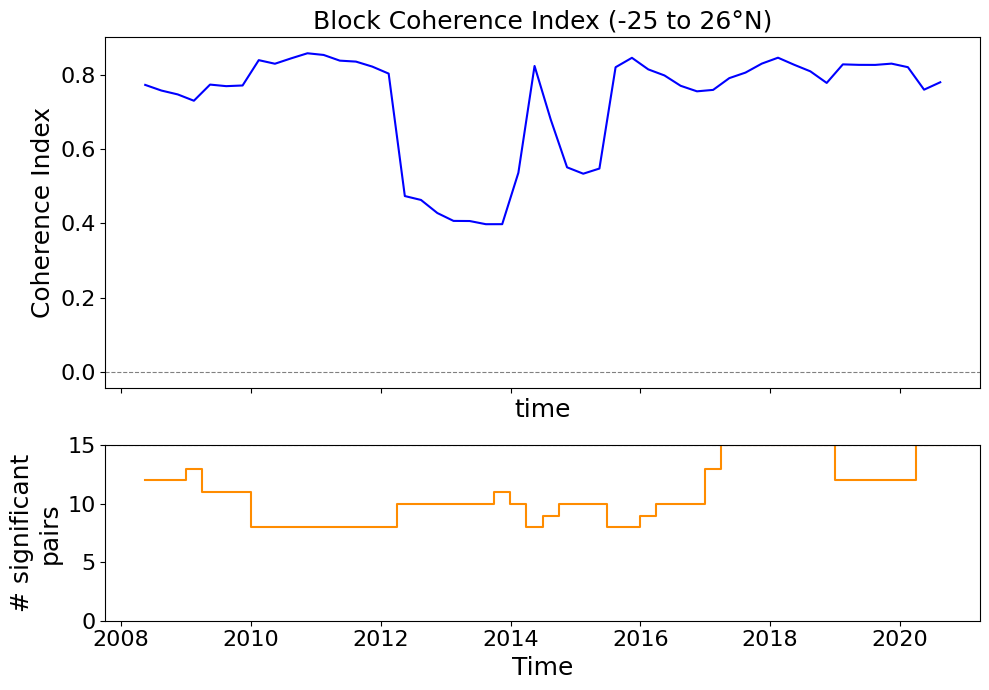

lat idx:  [5 6 7 8]


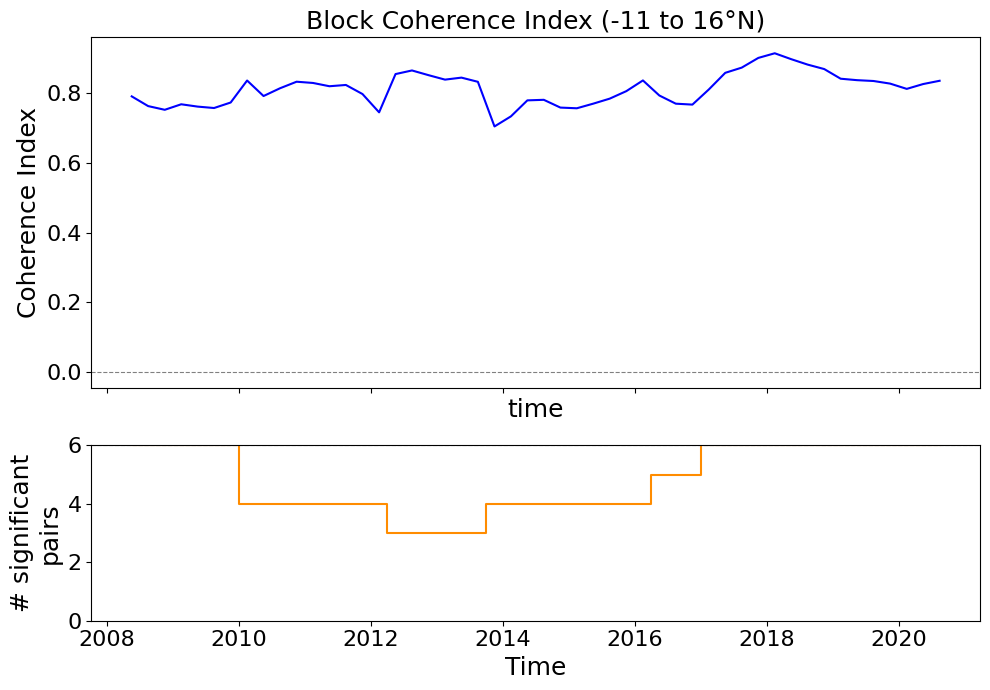

In [25]:

for lat_tuple in [(-35, 26), (-25, 26), (-11, 16)]:

    lat_min, lat_max = lat_tuple
    mask = (lats >= lat_min) & (lats <= lat_max)
    lat_idx = np.where(mask)[0]
    print("lat idx: ", lat_idx)

    coherence_idx, n_valid = block_coherence_index(
        mht_filtered,
        r_crits=r_crits_mht,
        lat_idx=lat_idx,
        lats=lats,
        window=16
    )
    total_pairs = len(lat_idx) * (len(lat_idx) - 1) // 2

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                     gridspec_kw={'height_ratios': [2, 1]})

    coherence_idx.plot(ax=ax1, color="blue")
    ax1.set_title(f"Block Coherence Index ({lat_tuple[0]} to {lat_tuple[1]}°N)")
    ax1.set_ylabel("Coherence Index")
    ax1.axhline(0, color="gray", linewidth=0.8, linestyle="--")

    n_valid.plot(ax=ax2, color="darkorange", drawstyle="steps-mid")
    ax2.set_ylabel("# significant\npairs")
    ax2.set_xlabel("Time")
    ax2.set_ylim(0, total_pairs)
    ax2.axhline(total_pairs, color="gray", linewidth=0.8, linestyle="--")

    plt.tight_layout()
    plt.show()

## boxes for 2 covarying bands

lat idx:  [ 6  7  8  9 10]


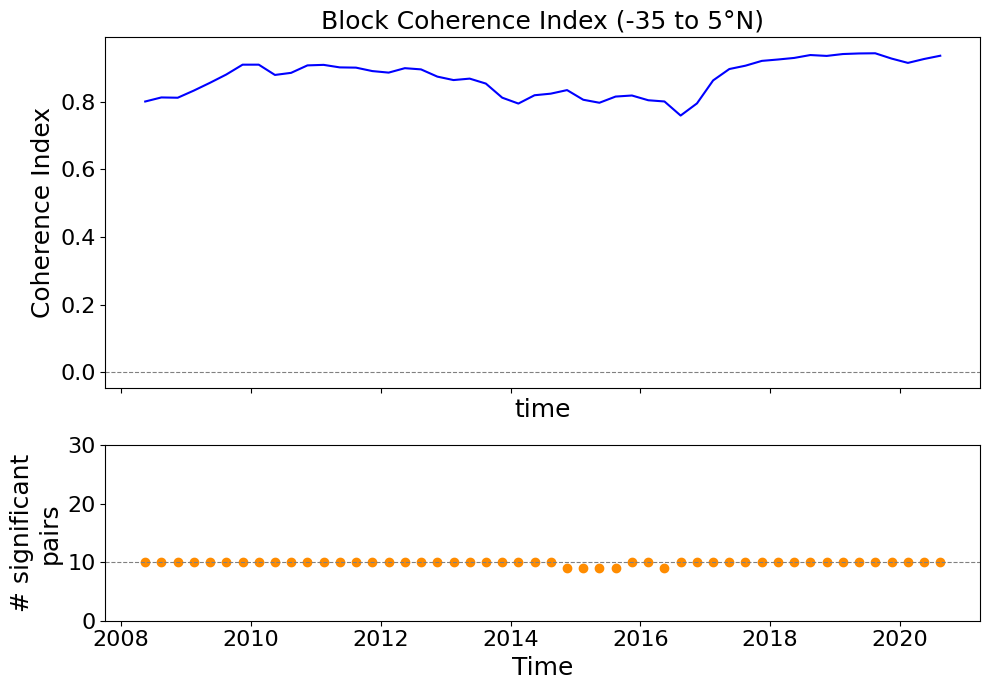

lat idx:  [3 4 5 6]


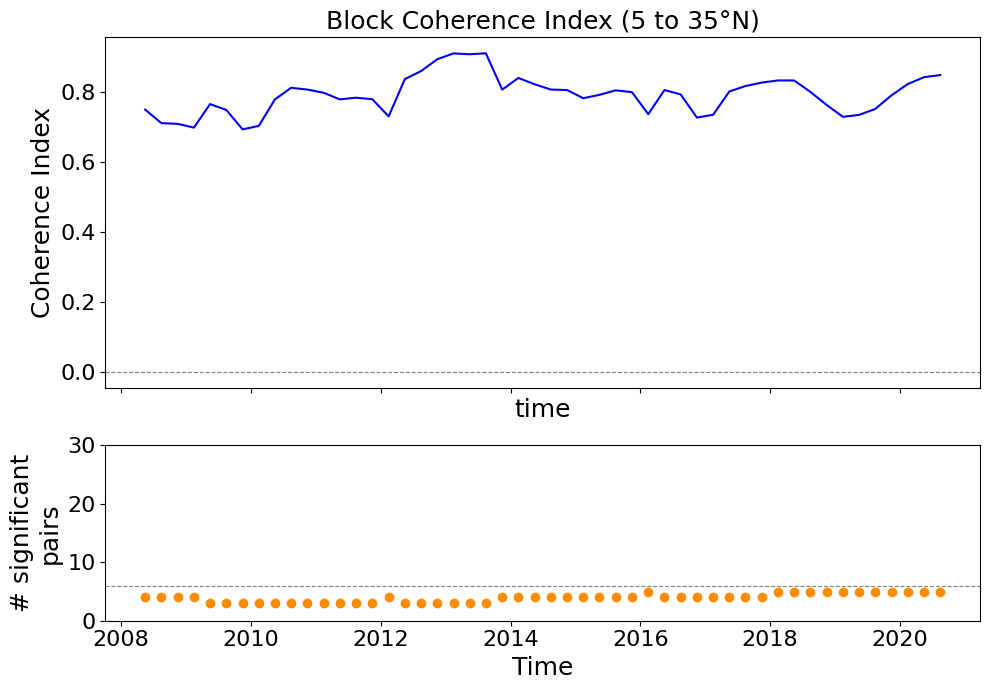

lat idx:  [3 4 5]


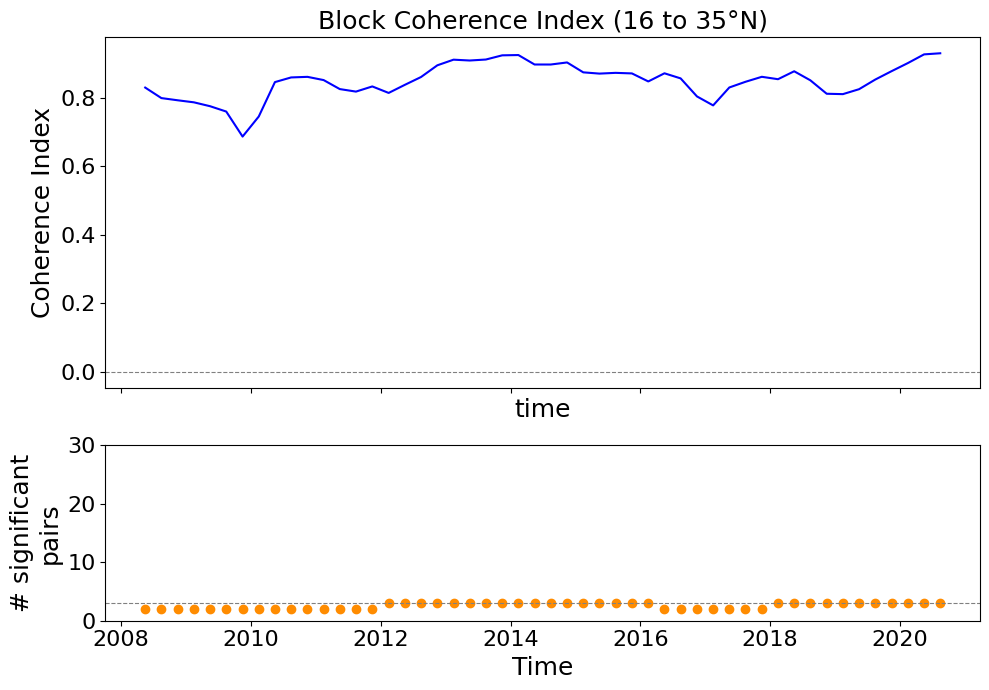

In [26]:
 
for lat_tuple in [(-35, 5), (5, 35) , (16,35)]:

    lat_min, lat_max = lat_tuple
    mask = (lats >= lat_min) & (lats <= lat_max)
    lat_idx = np.where(mask)[0]
    print("lat idx: ", lat_idx)

    coherence_idx, n_valid = block_coherence_index(
        mht_filtered,
        r_crits=r_crits_mht,
        lat_idx=lat_idx,
        lats=lats,
        window=16
    )
    total_pairs = len(lat_idx) * (len(lat_idx) - 1) // 2

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                     gridspec_kw={'height_ratios': [2, 1]})

    coherence_idx.plot(ax=ax1, color="blue")
    ax1.set_title(f"Block Coherence Index ({lat_tuple[0]} to {lat_tuple[1]}°N)")
    ax1.set_ylabel("Coherence Index")
    ax1.axhline(0, color="gray", linewidth=0.8, linestyle="--")

    # n_valid.plot(ax=ax2, color="darkäorange")
    ax2.scatter(n_valid.time, n_valid.values, color="darkorange")
    ax2.set_ylabel("# significant\npairs")
    ax2.set_xlabel("Time")
    ax2.set_ylim(0, 30)
    ax2.axhline(total_pairs, color="gray", linewidth=0.8, linestyle="--")

    plt.tight_layout()
    plt.show()

In [27]:
# lat_bounds = lats
# corr_full = compute_corr_matrix(mht_filtered, hf_filtered)
# plot_corr_heatmap(corr_full, lat_bounds, title="Full period (2004–2020)")



In [28]:
# corr_pre, corr_post = compare_pre_post(mht_filtered, hf_filtered, lat_bounds, split_date="2008-01-01")
